<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/02.Tokenization-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

<span style="font-size:2.5em">2. 텍스트 전처리 및 토큰화 (2)</span>  

이 자료는 다음 자료들을 기반으로 수정된 자료입니다.<br>
- [위키독스 딥 러닝을 이용한 자연어 처리 입문, 02. 텍스트 전처리(Text preprocessing)](https://wikidocs.net/21694)

#### 토근화 도구
- 영어 : spaCy, NLTK
- 한글 : KoNLPy

# 2.9 토큰화

### SpaCy
자연어 처리를 위한 Python 기반의 오픈 소스 라이브러리로, 다음과 같은 기능들을 제공한다.
- Tokenization
- Part-of-speech (POS) Tagging
- Depedency Parsing
- Lemmatization
- Sentence Boundary Detection (SBD)
- Named Entity Recognition (NER)
- Similarity
- Text Classification
- Rule-based Matching
- Training
- Serialization
- [spacy.io](https://spacy.io/models): spaCy를 위한 다운로드 가능한 사전훈련된 파이프라인 및 가중치

In [ ]:
import sys
!{sys.executable} -m pip install spacy

In [1]:
import spacy
spacy_en = spacy.load("en_core_web_sm")

In [2]:
import spacy

spacy_en = spacy.load("en_core_web_sm")
text = "A Dog Run back corner near spare bedrooms."
print(spacy_en.tokenizer(text))
print([tok.text for tok in spacy_en.tokenizer(text)])

A Dog Run back corner near spare bedrooms.
['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms', '.']


위에서 `spacy.load`에서 에러 발생시, 환경에서 다음을 우선 실행하고 다시 해보자.
```
python -m spacy download en
```

### NLTK

In [ ]:
import nltk
nltk.download('punkt')

In [3]:
from nltk.tokenize import word_tokenize
word_tokenize(text)

['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms', '.']

### 띄어쓰기 토큰화

In [4]:
text.split()

['A', 'Dog', 'Run', 'back', 'corner', 'near', 'spare', 'bedrooms.']

- 구두점만 제외하면 whitespace로 토큰화해도 충분히 쓸만 하다.

In [5]:
text = "사과의 놀라운 효능이라는 글을 봤어. 그래서 오늘 사과를 먹으려고 했는데 사과가 썩어서 슈퍼에 가서 사과랑 오렌지 사왔어."
print(text.split())

['사과의', '놀라운', '효능이라는', '글을', '봤어.', '그래서', '오늘', '사과를', '먹으려고', '했는데', '사과가', '썩어서', '슈퍼에', '가서', '사과랑', '오렌지', '사왔어.']


- '사과'가 4번 출현했는데, '-의', '-를', '-가', '-랑' 등 이 붙어 있어서 모두 다른 단어로 인식
- 한국어에서는 이를 방지하기 위해 형태소 분석기를 통해 토큰화를 수행한다.

### 한글 형태소분석기를 사용한 토큰화

```
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab
!bash install_mecab-ko_on_colab190912.sh
```

In [7]:
import sys
!{sys.executable} -m pip install eunjeon
!{sys.executable} -m pip install mecab-ko-dic

In [6]:
from eunjeon import Mecab
m = Mecab()
m.pos("이것은 메캅 테스트입니다. 사용자 사전을 등록하기 전입니다. 비타500")

[('이것', 'NP'),
 ('은', 'JX'),
 ('메', 'VV+EC'),
 ('캅', 'NNP'),
 ('테스트', 'NNG'),
 ('입니다', 'VCP+EF'),
 ('.', 'SF'),
 ('사용', 'NNG'),
 ('자', 'XSN'),
 ('사전', 'NNG'),
 ('을', 'JKO'),
 ('등록', 'NNG'),
 ('하', 'XSV'),
 ('기', 'ETN'),
 ('전', 'NNG'),
 ('입니다', 'VCP+EF'),
 ('.', 'SF'),
 ('비타', 'NNP'),
 ('500', 'SN')]

### 문자 단위 토큰화

In [8]:
text = "A Dog Run back corner near spare bedrooms."
print(list(text))

['A', ' ', 'D', 'o', 'g', ' ', 'R', 'u', 'n', ' ', 'b', 'a', 'c', 'k', ' ', 'c', 'o', 'r', 'n', 'e', 'r', ' ', 'n', 'e', 'a', 'r', ' ', 's', 'p', 'a', 'r', 'e', ' ', 'b', 'e', 'd', 'r', 'o', 'o', 'm', 's', '.']


# 2.10 어휘(Vocabulary) 생성

In [10]:
import urllib.request
import pandas as pd
from nltk import FreqDist
import numpy as np
import matplotlib.pyplot as plt

In [11]:
urllib.request.urlretrieve('https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt',
                           filename='ratings.txt'
                           )
data = pd.read_table('ratings.txt')
data[:10]

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1
5,2190435,사랑을 해본사람이라면 처음부터 끝까지 웃을수 있는영화,1
6,9279041,완전 감동입니다 다시봐도 감동,1
7,7865729,개들의 전쟁2 나오나요? 나오면 1빠로 보고 싶음,1
8,7477618,굿,1
9,9250537,바보가 아니라 병 쉰 인듯,1


In [12]:
print("전체 샘플의 수 : {}".format(len(data)))

전체 샘플의 수 : 200000


* 임의로 100개만 샘플링해서 연습

In [13]:
pd.options.mode.copy_on_write = True  # Pandas User Guide: User Guide>Copy-on-Write (CoW) 참조 
sample_data = data[:100]

In [14]:
sample_data['document'] = sample_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")
# 한글과 공백을 제외하고 모두 제거
sample_data.head(10)

,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1
5,2190435,사랑을 해본사람이라면 처음부터 끝까지 웃을수 있는영화,1
6,9279041,완전 감동입니다 다시봐도 감동,1
7,7865729,개들의 전쟁2 나오나요? 나오면 1빠로 보고 싶음,1
8,7477618,굿,1
9,9250537,바보가 아니라 병 쉰 인듯,1


In [15]:
stopwords=['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

In [16]:
tokenizer = Mecab()

In [17]:
tokenized = []
for sentence in sample_data['document']:
  temp = tokenizer.morphs(sentence)
  temp = [word for word in temp if not word in stopwords]
  tokenized.append(temp)

In [18]:
print(tokenized[:10])

[['어릴', '때', '보', '고', '지금', '다시', '봐도', '재밌', '어요', 'ㅋㅋ'], ['디자인', '을', '배우', '학생', ',', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '해', '문화', '산업', '부러웠', '는데', '.', '사실', '우리', '나라', '에서', '그', '어려운', '시절', '끝', '까지', '열정', '을', '지킨', '노라노', '같', '전통', '있', '어', '저', '같', '사람', '꿈', '을', '꾸', '고', '이뤄나갈', '수', '있', '다는', '것', '감사', '합니다', '.'], ['폴리스', '스토리', '시리즈', '1', '부터', '뉴', '까지', '버릴', '께', '하나', '없', '음', '.', '.', '최고', '.'], ['.', '.', '연기', '진짜', '개', '쩔', '구나', '.', '.', '지루', '할', '거', '라고', '생각', '했', '는데', '몰입', '해서', '봤', '다', '.', '.', '그래', '이런', '게', '진짜', '영화', '지'], ['안개', '자욱', '밤하늘', '떠', '있', '초승달', '같', '영화', '.'], ['사랑', '을', '해', '본', '사람', '라면', '처음', '부터', '끝', '까지', '웃', '을', '수', '있', '영화'], ['완전', '감동', '입니다', '다시', '봐도', '감동'], ['개', '전쟁', '2', '나오', '나요', '?', '나오', '면', '1', '빠', '로', '보', '고', '싶', '음'], ['굿'], ['바보', '아니', '라', '병', '쉰', '인', '듯']]


In [20]:
vocab = FreqDist(np.hstack(tokenized))
print("어휘(단어집합)의 크기 : {}".format(len(vocab)))

어휘(단어집합)의 크기 : 693


In [21]:
vocab["재밌"]

10

In [22]:
vocab_size = 500

vocab = vocab.most_common(vocab_size)
print("어휘(단어집합)의 크기 : {}".format(len(vocab)))

어휘(단어집합)의 크기 : 500


In [23]:
word2index = {word[0] : index + 2 for index, word in enumerate(vocab)}
word2index['pad'] = 1
word2index['unk'] = 0

In [24]:
encoded = []
for line in tokenized:
  temp = []
  for w in line:
    try:
      temp.append(word2index[w])
    except KeyError:
      temp.append(word2index['unk'])
  
  encoded.append(temp)

In [25]:
print(tokenized[:2])
print(encoded[:2])

[['어릴', '때', '보', '고', '지금', '다시', '봐도', '재밌', '어요', 'ㅋㅋ'], ['디자인', '을', '배우', '학생', ',', '외국', '디자이너', '그', '일군', '전통', '을', '통해', '발전', '해', '문화', '산업', '부러웠', '는데', '.', '사실', '우리', '나라', '에서', '그', '어려운', '시절', '끝', '까지', '열정', '을', '지킨', '노라노', '같', '전통', '있', '어', '저', '같', '사람', '꿈', '을', '꾸', '고', '이뤄나갈', '수', '있', '다는', '것', '감사', '합니다', '.']]
[[84, 32, 9, 5, 55, 47, 85, 19, 33, 34], [202, 6, 86, 203, 20, 204, 205, 56, 206, 121, 6, 207, 208, 24, 122, 209, 210, 15, 2, 57, 87, 123, 35, 56, 211, 124, 125, 36, 212, 6, 213, 214, 21, 121, 8, 58, 59, 21, 48, 215, 6, 216, 5, 217, 16, 8, 88, 37, 218, 89, 2]]


리뷰의 최대 길이 : 62
리뷰의 최소 길이 : 1
리뷰의 평균 길이 : 15.600000


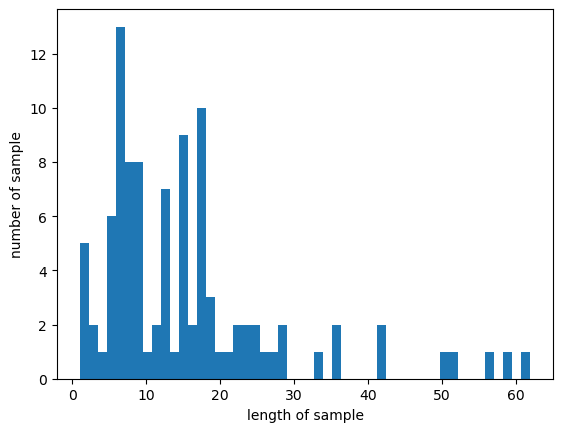

In [26]:
max_len = max(len(l) for l in encoded)
print('리뷰의 최대 길이 : %d' % max_len)
print('리뷰의 최소 길이 : %d' % min(len(l) for l in encoded))
print('리뷰의 평균 길이 : %f' % (sum(map(len, encoded))/len(encoded)))
plt.hist([len(s) for s in encoded], bins=50)
plt.xlabel('length of sample')
plt.ylabel('number of sample')
plt.show()

In [27]:
for line in encoded:
  if len(line) < max_len:
    line += [word2index['pad']] * (max_len - len(line))

In [28]:
print('리뷰의 최대 길이 : %d' % max(len(l) for l in encoded))
print('리뷰의 최소 길이 : %d' % min(len(l) for l in encoded))
print('리뷰의 평균 길이 : %f' % (sum(map(len, encoded))/len(encoded)))

리뷰의 최대 길이 : 62
리뷰의 최소 길이 : 62
리뷰의 평균 길이 : 62.000000


In [29]:
print(encoded[:2])
# 단어들을 고유한 정수로 매핑 완료.
# 각 정수를 고유한 단어 벡터로 바꾸는 작업(원핫 인코딩 / 워드 임베딩)이 필요함

[[84, 32, 9, 5, 55, 47, 85, 19, 33, 34, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [202, 6, 86, 203, 20, 204, 205, 56, 206, 121, 6, 207, 208, 24, 122, 209, 210, 15, 2, 57, 87, 123, 35, 56, 211, 124, 125, 36, 212, 6, 213, 214, 21, 121, 8, 58, 59, 21, 48, 215, 6, 216, 5, 217, 16, 8, 88, 37, 218, 89, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]
